## 1 Import the CSV file and preview a few rows

We load the `lab07_customers.csv` dataset into a pandas DataFrame and display the first few rows to examine its structure and variable types.


In [5]:
import pandas as pd

# Read the CSV file
CSV_PATH = "lab07_customers.csv"
df = pd.read_csv(CSV_PATH)

# Preview the first few rows
display(df.head())

# Check general information about the dataset
df.info()


,race,income,sex,schoolYears,age,spend
0,white,157966.0,male,18.0,31.0,659.97
1,white,11134.0,female,14.0,50.0,719.69
2,hispanic,555369.0,male,14.0,32.0,854.61
3,white,272387.0,female,18.0,52.0,855.20
4,white,105459.0,female,17.0,49.0,758.33


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   race         10000 non-null  object 
 1   income       10000 non-null  float64
 2   sex          10000 non-null  object 
 3   schoolYears  10000 non-null  float64
 4   age          10000 non-null  float64
 5   spend        10000 non-null  float64
dtypes: float64(4), object(2)
memory usage: 468.9+ KB


## 2 Compute descriptive statistics

We summarize all numerical variables and compute counts and percentages for each category of the categorical variables (`race` and `sex`).


In [6]:
# Descriptive statistics for numeric variables
display(df.describe())

# Frequency counts and percentages for categorical variables
for col in ['race', 'sex']:
    print(f"\nDistribution of {col}:")
    print(df[col].value_counts())  # counts
    print("\nPercentage of each category:")
    print(df[col].value_counts(normalize=True) * 100)  # percentages


,income,schoolYears,age,spend
count,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,8.531690e+04,15.186000,41.982300,755.376206
std,1.096255e+05,2.225151,8.967498,115.994785
min,1.195000e+03,9.000000,18.000000,331.580000
25%,2.649025e+04,14.000000,34.000000,692.212500
50%,5.215300e+04,15.000000,42.000000,761.120000
75%,1.011165e+05,17.000000,50.000000,818.847500
max,2.100000e+06,22.000000,67.000000,1329.340000



Distribution of race:
race
white       5771
hispanic    1405
black       1163
other       1094
asian        567
Name: count, dtype: int64

Percentage of each category:
race
white       57.71
hispanic    14.05
black       11.63
other       10.94
asian        5.67
Name: proportion, dtype: float64

Distribution of sex:
sex
male      5006
female    4982
other       12
Name: count, dtype: int64

Percentage of each category:
sex
male      50.06
female    49.82
other      0.12
Name: proportion, dtype: float64


## 3 Clean categorical variables

To simplify the dataset, we remove all observations where `sex = 'other'` and combine `asian` with the `other` race category as instructed.


In [7]:
# Remove rows where sex == 'other'
df = df[df['sex'] != 'other']

# Combine 'asian' with 'other' race category
df['race'] = df['race'].replace({'asian': 'other'})

# Verify the changes
print("Unique values in 'sex':", df['sex'].unique())
print("Unique values in 'race':", df['race'].unique())

# Check updated counts after cleaning
print("\nUpdated counts for sex:")
print(df['sex'].value_counts())

print("\nUpdated counts for race:")
print(df['race'].value_counts())


Unique values in 'sex': ['male' 'female']
Unique values in 'race': ['white' 'hispanic' 'black' 'other']

Updated counts for sex:
sex
male      5006
female    4982
Name: count, dtype: int64

Updated counts for race:
race
white       5763
other       1660
hispanic    1403
black       1162
Name: count, dtype: int64


## 4 Examine distributions of continuous variables

We visualize the distributions of the continuous variables to assess normality.  
If `income` appears highly skewed, we apply a log transformation to improve its distribution.


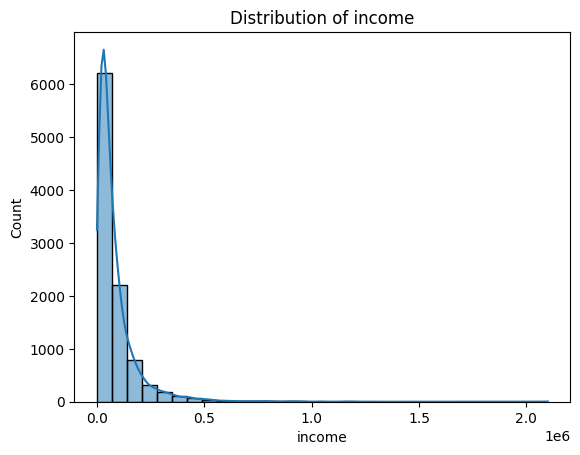

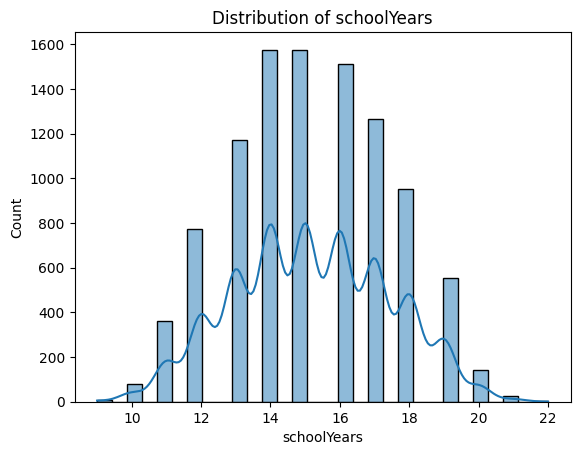

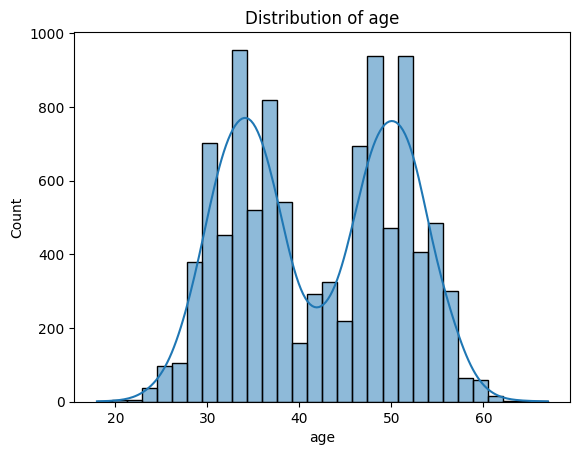

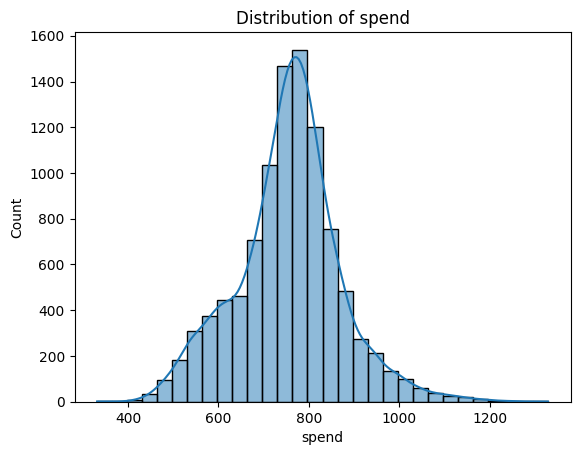

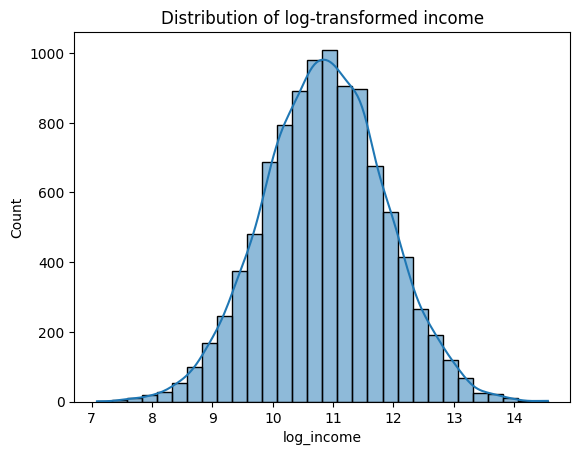

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Continuous variables
cont_cols = ['income', 'schoolYears', 'age', 'spend']

# Plot histograms for each continuous variable
for col in cont_cols:
    plt.figure()
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Apply log transformation if income is right-skewed
df['log_income'] = np.log1p(df['income'])

# Check transformed distribution
plt.figure()
sns.histplot(df['log_income'], bins=30, kde=True)
plt.title("Distribution of log-transformed income")
plt.show()


## 5 Compute average spending by race

We calculate the mean value of `spend` for each race group to compare customer spending patterns across racial categories.


In [9]:
# Average spending by race
avg_spend_race = df.groupby('race')['spend'].mean().round(2)
display(avg_spend_race)


race
black       643.75
hispanic    824.59
other       769.99
white       757.33
Name: spend, dtype: float64

## 6 Compute average spending by sex

We compute the mean value of `spend` for each sex group to compare spending behavior between males and females.


In [10]:
# Average spending by sex
avg_spend_sex = df.groupby('sex')['spend'].mean().round(2)
display(avg_spend_sex)


sex
female    752.96
male      758.36
Name: spend, dtype: float64

## 7a Test for race × sex interaction

We fit a two-way ANOVA model with `spend` as the dependent variable and `race`, `sex`, and their interaction as predictors.  
We then test whether the interaction between race and sex is statistically significant.


In [11]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Two-way ANOVA model with interaction
model_interaction = ols('spend ~ C(race) * C(sex)', data=df).fit()

# Type III ANOVA to test overall interaction effect
anova_table = sm.stats.anova_lm(model_interaction, typ=3)
display(anova_table)


,sum_sq,df,F,PR(>F)
Intercept,1.865948e+08,1.0,19774.240750,0.000000e+00
C(race),2.647081e+07,3.0,935.074521,0.000000e+00
C(sex),8.805147e+06,1.0,933.118758,5.399944e-196
C(race):C(sex),1.801462e+07,3.0,636.361984,0.000000e+00
Residual,9.417383e+07,9980.0,NaN,NaN


## 7b Report p-values and adjusted R²

We report the individual term p-values and the model’s adjusted R² to evaluate model fit.


In [12]:
# Display p-values for each term in the model
print("P-values for model terms:")
print(model_interaction.pvalues)

# Display adjusted R-squared
print("\nAdjusted R-squared:", round(model_interaction.rsquared_adj, 4))


P-values for model terms:
Intercept                              0.000000e+00
C(race)[T.hispanic]                   1.812852e-297
C(race)[T.other]                       0.000000e+00
C(race)[T.white]                       0.000000e+00
C(sex)[T.male]                        5.399944e-196
C(race)[T.hispanic]:C(sex)[T.male]     5.033655e-12
C(race)[T.other]:C(sex)[T.male]       8.245216e-237
C(race)[T.white]:C(sex)[T.male]       2.922299e-231
dtype: float64

Adjusted R-squared: 0.2958


## 7c Pivot table of mean spending by race and sex

We create a pivot table showing the mean value of `spend` by both `race` and `sex`.  
This helps visualize group-level differences found in the ANOVA results.


In [13]:
# Create pivot table: mean spend by race and sex
pivot_table = df.pivot_table(values='spend', index='race', columns='sex', aggfunc='mean').round(2)
display(pivot_table)


sex,female,male
race,,
black,559.07,733.23
hispanic,764.88,885.76
other,810.17,733.23
white,774.44,740.21


## 7d Findings summary

The interaction between race and sex is statistically significant (p < 0.001).  
From the pivot table, Hispanic males have the highest mean spending, while Black females have the lowest.  
These findings support the hypothesis that certain race–sex combinations differ in spending behavior.


## 8 Test a three-way interaction with schoolYears

We fit a linear model including race, sex, schoolYears, and all interactions among them.  
We then test whether the three-way interaction (`race × sex × schoolYears`) is significant and report the adjusted R² value.


In [14]:
# Three-way interaction model
model_3way = ols('spend ~ C(race) * C(sex) * schoolYears', data=df).fit()

# Type III ANOVA for three-way interaction
anova_3way = sm.stats.anova_lm(model_3way, typ=3)
display(anova_3way)

# Report adjusted R-squared
print("\nAdjusted R-squared:", round(model_3way.rsquared_adj, 4))


,sum_sq,df,F,PR(>F)
Intercept,2.571222e+06,1.0,285.098927,4.355748e-63
C(race),6.259299e+05,3.0,23.134517,6.437201e-15
C(sex),5.465202e+04,1.0,6.059855,1.384570e-02
C(race):C(sex),4.005032e+05,3.0,14.802692,1.295754e-09
schoolYears,1.220067e+05,1.0,13.528186,2.362433e-04
C(race):schoolYears,6.521364e+05,3.0,24.103116,1.551550e-15
C(sex):schoolYears,3.623977e+04,1.0,4.018291,4.503628e-02
C(race):C(sex):schoolYears,5.492180e+05,3.0,20.299229,4.133926e-13
Residual,8.993449e+07,9972.0,NaN,NaN



Adjusted R-squared: 0.3269


### 8 Results summary for the three-way interaction

The three-way interaction among race, sex, and schoolYears is statistically significant (p < 0.001).  
This indicates that the effect of education on spending differs depending on both race and sex.  
The model’s adjusted R² = 0.3003, suggesting a moderate overall fit.


## 9 Interaction plot: schoolYears × sex

We visualize the interaction between `schoolYears` and `sex` on `spend`.  
The x-axis represents `schoolYears`, and separate lines show spending patterns for each sex group.


<Figure size 800x600 with 0 Axes>

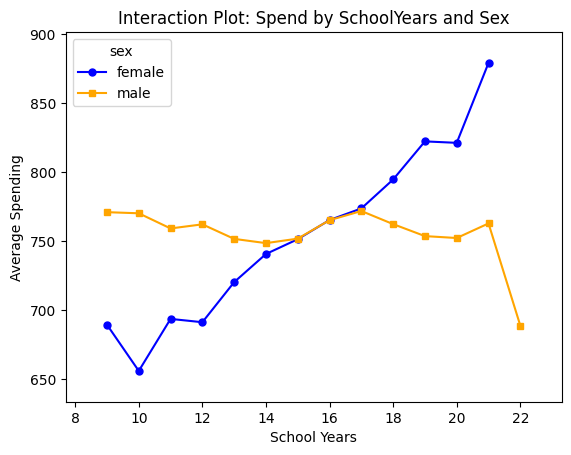

In [15]:
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt

# Interaction plot: spend by schoolYears and sex
plt.figure(figsize=(8, 6))
interaction_plot(
    x=df['schoolYears'],
    trace=df['sex'],
    response=df['spend'],
    colors=['blue', 'orange'],
    markers=['o', 's'],
    ms=5
)
plt.title('Interaction Plot: Spend by SchoolYears and Sex')
plt.xlabel('School Years')
plt.ylabel('Average Spending')
plt.show()


## 10 Summary of findings

Overall, customer spending varies significantly by race, sex, and education level.  
Race and sex interact to influence spending, with Hispanic males spending the most and Black females the least.  
Education (schoolYears) further moderates this relationship — females with higher education levels tend to spend more, while males show little change.  
These findings suggest that demographic and educational factors jointly affect customer spending behavior.
